# Parameter scenarios for the graph SIR model

This script extends the base experiment with several parameter scenarios:
heterogeneous transmission, faster migration, and slower detection.

## Libraries and project activation

In [1]:
using DrWatson
@quickactivate "lab_04_models"

ENV["GKSwstype"] = "100"

include(srcdir("sir_analysis.jl"))

scenario_comparison_plot (generic function with 1 method)

## Scenario list

Each scenario modifies a small set of parameters while keeping the model
structure unchanged.

In [2]:
scenarios = scenario_parameters()
summaries = NamedTuple[]

for spec in scenarios
    global_df, city_df, summary = run_scenario(spec)
    scenario_plot = plot_scenario(global_df, city_df; title = spec[:label])
    scenario_plot
    plot_name = "scenario_" * spec[:label] * ".png"


    push!(summaries, summary)
end

summary_df = DataFrame(summaries)
summary_df

Row,scenario,peak_infected,peak_fraction,peak_time,final_recovered,deaths
,String,Int64,Float64,Int64,Int64,Int64
1,baseline,3000,1.0,20,63,390
2,heterogeneous_beta,2999,0.999667,21,108,392
3,fast_migration,3000,1.0,18,120,412
4,slow_detection,3000,1.0,21,21,433


## Scenario comparison

We compare peak infection fractions and death counts across all scenarios.

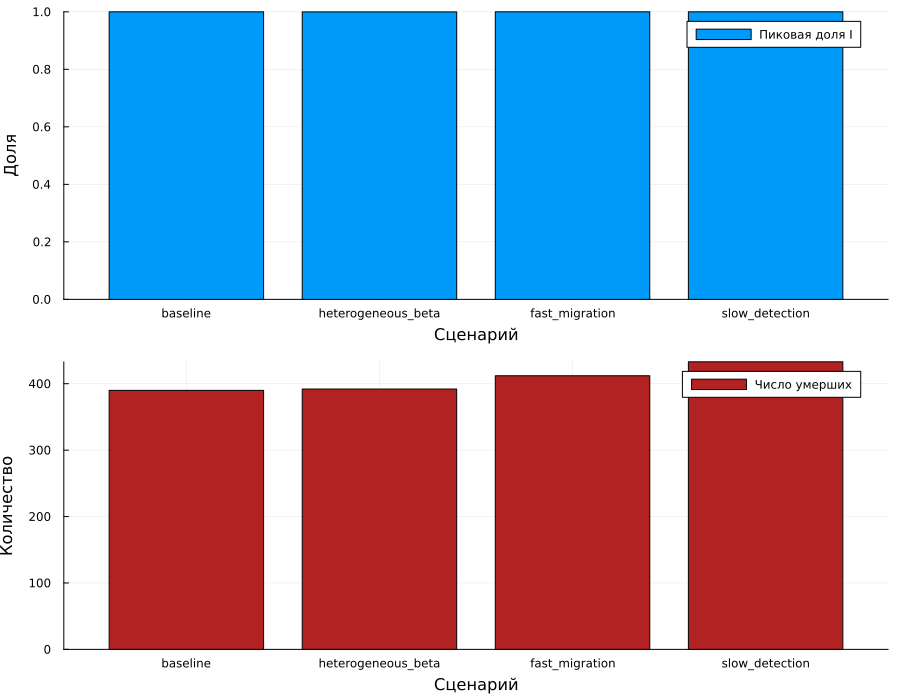

In [3]:
comparison_plot = scenario_comparison_plot(summary_df)
comparison_plot

## Conclusions

1. Heterogeneous transmission shifts the infection burden toward the first city.
2. Faster migration reduces the time to epidemic peak.
3. Slower detection increases both the peak load and the number of deaths.